<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация и классическая векторизация текстов**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [81]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, roc_auc_score

# дополним для задания 2
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

Populating the interactive namespace from numpy and matplotlib


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/pylab.py:159: UserWarning: pylab import has clobbered these variables: ['hstack', 'scatter', 'axes']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [82]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        if self.w0 is None:
            # Инициализируем веса случайными значениями, как в нейросетях
            self.w = np.random.randn(X.shape[1]) * 0.01
        else:
            # Если веса переданы явно, копируем их, чтобы не менять исходный объект
            self.w = self.w0.copy()

        self.loss_history = []

        for i in range(self.max_iter):
            current_loss = self.calc_loss(X, y) # Вычисляем лосс
            self.loss_history.append(current_loss) # Сохраняем лосс

            if self.gd_type == 'full':
                X_batch = X
                y_batch = y
            elif self.gd_type == 'stochastic':
                # Для стохастического спуска генерируем один случайный индекс
                idx = np.random.randint(X.shape[0])
                X_batch = X[idx:idx+1] # Выбираем один объект как матрицу 1хd
                y_batch = y[idx:idx+1] # Выбираем соответствующую метку класса

            # Вычисляем градиент лосса
            grad = self.calc_gradient(X_batch, y_batch)

            # Вычисляем новые веса
            new_w = self.w - self.eta * grad

            # Проверка критерия останова
            if np.linalg.norm(new_w - self.w) < self.tolerance:

                # Применяем обновленные веса, если выолнен критерий
                self.w = new_w
                break

            # Применяем обновленные веса, если не выолнен критерий
            self.w = new_w

        return self

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        predicted_probability = self.sigmoid(X @ self.w)

        return predicted_probability


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        proba = self.predict_proba(X)

        # Gemini подсказывает, что можно
        # вот так в одну строчку создать маску
        # True/False в соответствии с условием
        # и перевести в 0 и 1
        return (proba > 0.5).astype(int)


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !

        predictions = self.sigmoid(X @ self.w)

        diff = predictions - y

        # для себя

        # транспонирование нужно, чтобы
        # собрать вклад всех объектов в
        # градиент каждого веса

        grad = (X.T @ diff) / X.shape[0]

        return grad


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        p = self.predict_proba(X)

        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

        return loss


Теперь проверим работу вашего класса на синтетических данных.

In [83]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [84]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


LogReg(gd_type='full')

SGD (Custom)    -> Accuracy: 0.8623, ROC-AUC: 0.9359
Full GD (Custom)-> Accuracy: 0.8658, ROC-AUC: 0.9388
Sklearn         -> Accuracy: 0.8681, ROC-AUC: 0.9399


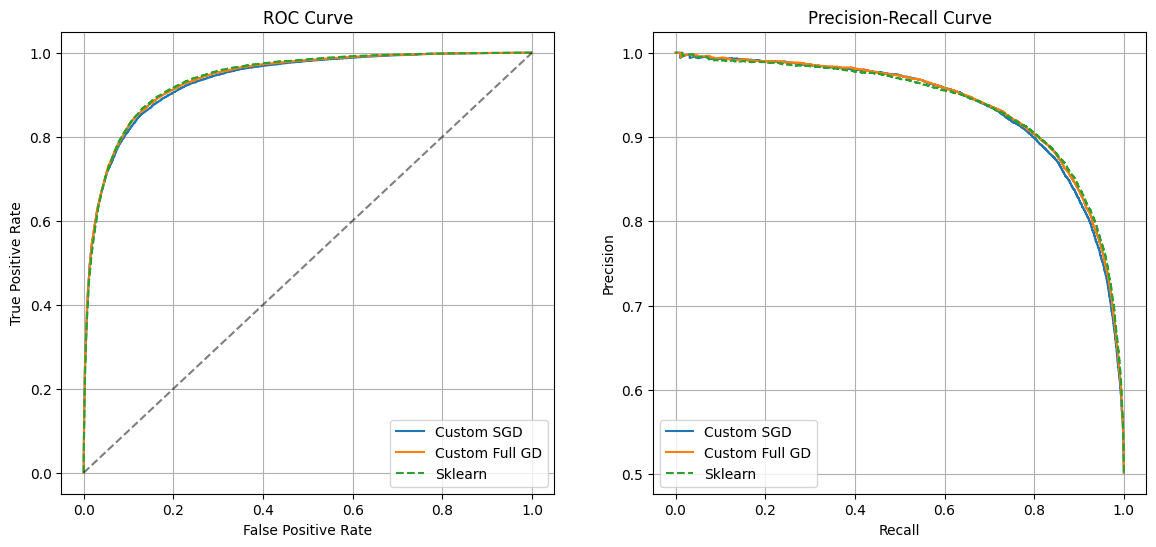

In [85]:
# sklearn
sk_model = LogisticRegression(random_state=42)
sk_model.fit(X_train, y_train)

# Для наших моделей predict_proba возвращает одномерный массив
y_pred_sgd = lr_sgd.predict(X_test)
y_proba_sgd = lr_sgd.predict_proba(X_test)

y_pred_full = lr_full.predict(X_test)
y_proba_full = lr_full.predict_proba(X_test)

# Для sklearn predict_proba возвращает Nx2, берем второй столбец (класс 1)
y_pred_sk = sk_model.predict(X_test)
y_proba_sk = sk_model.predict_proba(X_test)[:, 1]


# Форматирование вывода подсчитанных метрик и отрисовку графиков я делегировал Gemini


# метрики
print(f"SGD (Custom)    -> Accuracy: {accuracy_score(y_test, y_pred_sgd):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_sgd):.4f}")
print(f"Full GD (Custom)-> Accuracy: {accuracy_score(y_test, y_pred_full):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_full):.4f}")
print(f"Sklearn         -> Accuracy: {accuracy_score(y_test, y_pred_sk):.4f}, ROC-AUC: {roc_auc_score(y_test, y_proba_sk):.4f}")

# графики
plt.figure(figsize=(14, 6))
# ROC-AUC
plt.subplot(1, 2, 1)
fpr_sgd, tpr_sgd, _ = roc_curve(y_test, y_proba_sgd)
fpr_full, tpr_full, _ = roc_curve(y_test, y_proba_full)
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)

plt.plot(fpr_sgd, tpr_sgd, label='Custom SGD')
plt.plot(fpr_full, tpr_full, label='Custom Full GD')
plt.plot(fpr_sk, tpr_sk, '--', label='Sklearn')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# PR-кривая
plt.subplot(1, 2, 2)
p_sgd, r_sgd, _ = precision_recall_curve(y_test, y_proba_sgd)
p_full, r_full, _ = precision_recall_curve(y_test, y_proba_full)
p_sk, r_sk, _ = precision_recall_curve(y_test, y_proba_sk)

plt.plot(r_sgd, p_sgd, label='Custom SGD')
plt.plot(r_full, p_full, label='Custom Full GD')
plt.plot(r_sk, p_sk, '--', label='Sklearn')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

plt.show()

### 1. Какая модель показывает лучший результат? Почему?

**Лучший результат показывает модель из библиотеки `sklearn`.**
*   **Accuracy:** 0.8681 (против 0.8657 у Full GD и 0.8617 у SGD).
*   **ROC-AUC:** 0.9399 (против 0.9388 у Full GD и 0.9358 у SGD).

**Почему `sklearn` лучше:**
1.  **Продвинутые методы оптимизации:** Sklearn по умолчанию использует алгоритм подбора весов `lbfgs` (Limited-memory BFGS). Это метод второго порядка, который сходится к минимуму гораздо быстрее и точнее, чем обычный градиентный спуск  с фиксированным шагом.
2.  **Регуляризация:** Sklearn применяет L2-регуляризацию по умолчанию. Это помогает избежать переобучения и делает модель более устойчивой.

**Почему `Full GD` лучше `SGD`:**
*   `Full GD` (0.9388) работает лучше `SGD` (0.9358), так как на каждом шаге он использует все данные для вычисления градиента. Это дает правильное направление спуска без шума.
*   `SGD` использует всего один пример для шага. Из-за этого траектория спуска шумная, и в конце обучения веса могут плавать вокруг минимума, не попадая в самую точную точку, что и дает небольшое падение метрик.

### 2. Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели?

Да, в документации `sklearn.linear_model.LogisticRegression` есть несколько ключевых параметров, которые отличают её от нашей реализации:

1.  **`penalty='l2'`**:
    *   **Sklearn:** По умолчанию добавляет штраф за большие веса в функцию потерь. Это меняет саму задачу оптимизации.
    *   **Моя модель:** Минимизирует чистый LogLoss. Отсутствие регуляризации может приводить к тому, что веса становятся слишком большими, пытаясь подстроиться под шум в обучающих данных.

2.  **`fit_intercept=True`**:
    *   **Sklearn:** Автоматически добавляет свободный коэффициент. Это позволяет разделяющей гиперплоскости смещаться относительно начала координат.
    *   **Моя модель:** В реализации `z = X @ w`, если мы вручную не добавили столбец из единиц в матрицу `X` перед обучением (мне показалось, что можно это не делать, так как явно не требуется), наша гиперплоскость всегда проходит через начало координат. Это сильное ограничение, которое снижает точность. Хотя `StandardScaler` частично решает эту проблему, центрируя данные.

3.  **`solver='lbfgs'`**:
    *   Sklearn использует более сложный алгоритм поиска минимума, который динамически подбирает длину шага, в то время как у нас шаг фиксированный.

4.  **`tol` (Критерий остановки)**:
    *   У Sklearn и у нас этот параметр есть, но алгоритмы подбора весов Sklearn проверяют сходимость по норме градиента или изменению функции потерь более сложным способом, чем простая евклидова норма разности весов.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

**В курсах магистратуры я не понмю, чтобы был подробный разбор PCA (хотя скорее всего я мог пропустить), поэтому попросил Gemini составить заметку о том, как работает этот метод, чтобы более качественно с ним разобраться.**

***

# 🧠 Шпаргалка: PCA (Метод Главных Компонент)

**PCA (Principal Component Analysis)** — это один из самых популярных алгоритмов обучения без учителя. Его главная цель — уменьшить размерность данных, потеряв как можно меньше полезной информации.

Представь, что ты хочешь сфотографировать чайник. Чайник трехмерный (3D), а фотография — двухмерная (2D). Чтобы фото было информативным, ты будешь искать такой ракурс, где чайник максимально развернут и видны его детали (носик, ручка), а не просто плоский круг (вид сверху).
**PCA делает то же самое с данными: он ищет "лучший ракурс" (проекцию), чтобы увидеть структуру данных.**

---

## 🛠 Как это работает

Алгоритм работает в 4 шага:

1.  **Центрирование:** Сдвигает облако точек так, чтобы его центр находился в начале координат (среднее значение = 0). Это важно, потому что PCA ищет разброс данных.
2.  **Поиск самого большого разброса (PC1):** Алгоритм ищет линию, вдоль которой точки разбросаны сильнее всего. Это направление называется **Первой Главной Компонентой**. Оно содержит максимум информации о данных.
3.  **Поиск следующего направления (PC2):** Алгоритм ищет вторую линию, которая:
    *   Перпендикулярна первой (ортогональна).
    *   Содержит максимальный оставшийся разброс.
4.  **Проекция:** Мы поворачиваем оси так, чтобы PC1 стала осью X, а PC2 — осью Y. Все остальные (менее важные) измерения мы просто отбрасываем.

> **Важно:** PCA "любит" данные одного масштаба. Если один признак измеряется в миллионах, а другой в долях единицы, PCA решит, что миллионы важнее. Поэтому перед PCA мы всегда делаем масштабирование
---

После прочтения остались вопросы: а PCA всегда приводит к двумерному масштабу? И как именно он "ищет линию, вдоль которой точки разбросаны сильнее всего"?

---

### 1. Всегда ли PCA приводит к 2D (двумерному виду)?

**Нет, совсем не обязательно.**

Ты сам решаешь, до скольки измерений сжимать данные, задавая параметр `n_components`.
Обычно выбирают `n_components=2`, чтобы **нарисовать** график (экраны у нас плоские).

В реальных задачах обычно поступают так:
*   **Для визуализации:** сжимают до **2** или **3** компонент (чтобы построить 2D или 3D график).
*   **Для обучения моделей (предобработка):** сжимают до такого количества, которое сохраняет 90–99% информации (дисперсии).
    *   *Пример:* У тебя есть картинки 100x100 пикселей (10 000 признаков). Ты делаешь PCA и оставляешь **100** компонент. Ты сжал данные в 100 раз, но сохранил суть картинки, и модель обучится гораздо быстрее.

---

### 2. Как именно он "ищет линию с максимальным разбросом"? (Магия линейной алгебры)

Здесь нет перебора вариантов ("а давайте попробуем эту линию, нет, давайте ту"). Всё решается строго математически через **Матрицу ковариации**.

Вот пошаговый алгоритм того, что происходит внутри `.fit()`:

#### Шаг 1: Матрица ковариации
Представь, что у нас есть таблица данных (где столбцы — это признаки). PCA сначала строит **Матрицу ковариации**.
Это квадратная таблица, которая показывает, как признаки зависят друг от друга:
*   Если признак А растет, и Б растет — ковариация положительная.
*   Если они никак не связаны — ковариация близка к нулю.

> Эта матрица описывает "форму" облака твоих данных.

#### Шаг 2: Собственные векторы и собственные числа (Eigenvectors & Eigenvalues)
Это самый важный момент. Из линейной алгебры мы знаем, что у любой квадратной матрицы (в нашем случае — матрицы ковариации) можно найти особенные векторы.

*   **Собственные векторы (Eigenvectors):** Это направления осей, вдоль которых облако данных вытянуто (или сплюснуто). Они показывают *ориентацию* эллипса данных.
*   **Собственные числа (Eigenvalues):** Это числа, которые показывают *длину* этого вытягивания. Чем больше число, тем больше разброс данных вдоль этого вектора.

**PCA просто решает уравнение поиска собственных векторов и чисел для матрицы ковариации.**

#### Шаг 3: Сортировка (Рейтинг важности)
Допустим, у нас было 20 признаков. Мы нашли 20 собственных векторов и 20 собственных чисел.
1.  Мы сортируем их по величине **собственного числа** (от большего к меньшему).
2.  Вектор с самым большим числом — это **PC1** (первая главная компонента). Вдоль него самый сильный разброс.
3.  Вектор со вторым по величине числом — это **PC2**. Он перпендикулярен первому.
4.  ...и так далее.

#### Шаг 4: Проекция
Если мы хотим сжать данные до 2D, мы просто берем два первых вектора (с самыми большими собственными числами), формируем из них новую систему координат и проецируем на них все наши точки.

### Аналогия с регбийным мячом 🏉
Представь, что твои данные — это облако точек в форме регбийного мяча, висящего в пространстве под наклоном.

1.  **Центрирование:** PCA находит центр мяча и переносит начало координат туда.
2.  **Поиск PC1:** PCA математически находит ось, проходящую через мяч от одного острого конца до другого. Это самая длинная ось. Это **первая компонента**.
3.  **Поиск PC2:** PCA ищет следующую самую широкую ось, которая строго перпендикулярна первой (грубо говоря, "толщина" мяча).
4.  **Результат:** Если мы спроецируем мяч на эти две оси, мы получим максимально подробный "чертеж" мяча, сохранив его длину и ширину, и отбросив лишь незначительные неровности.

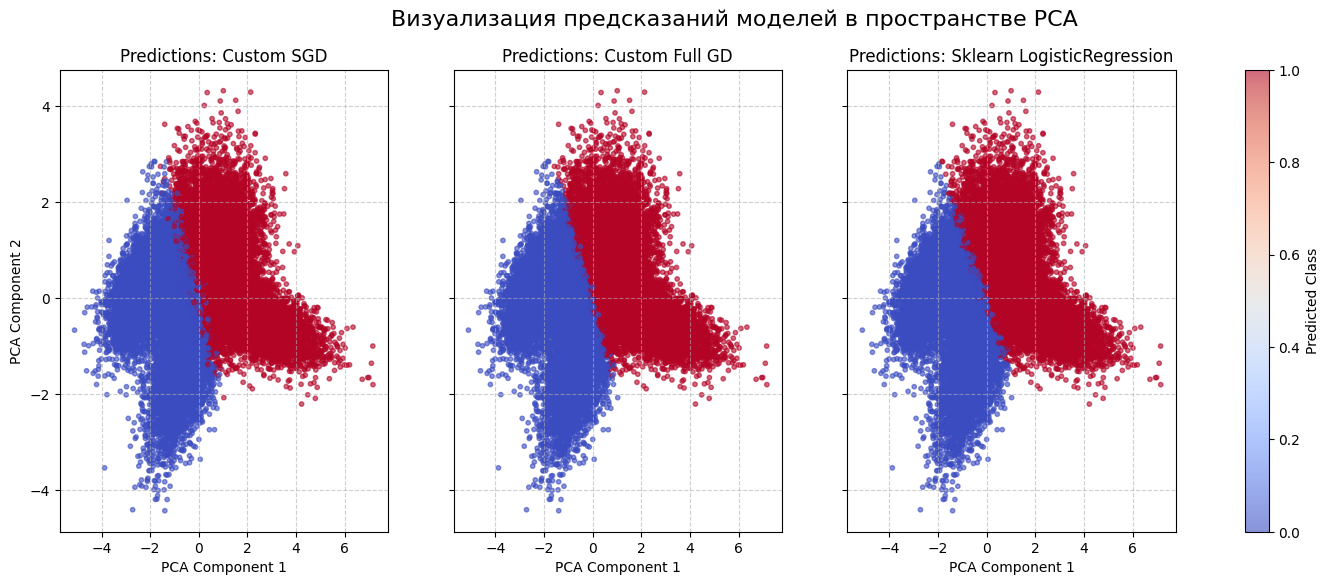

In [86]:
# 1. Применяем PCA для сжатия данных в двумерное пространство
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# 2. Подготовка данных для циклического построения графиков
# Список кортежей: (Название модели, Предсказанные классы)
models_preds = [
    ('Custom SGD', y_pred_sgd),
    ('Custom Full GD', y_pred_full),
    ('Sklearn LogisticRegression', y_pred_sk)
]

# 3. Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (model_name, preds) in enumerate(models_preds):
    # c=preds — красим точки в зависимости от предсказанного класса (0 или 1)
    # cmap='coolwarm' — цветовая карта (синий - 0, красный - 1)
    scatter = axes[i].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=preds, cmap='coolwarm', s=10, alpha=0.6)

    axes[i].set_title(f'Predictions: {model_name}')
    axes[i].set_xlabel('PCA Component 1')
    if i == 0:
        axes[i].set_ylabel('PCA Component 2')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# лгенда цветов
fig.colorbar(scatter, ax=axes.ravel().tolist(), label='Predicted Class')
plt.suptitle('Визуализация предсказаний моделей в пространстве PCA', fontsize=16)
plt.show()

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [87]:
# здесь был трейн_тест_сплит, но он ведь уже импортирован в самом верху...

# Для воспроизводимостия я нашёл в интернете ссылку на данные и предлагаю читать их напрямую
PATH = 'https://raw.githubusercontent.com/Krishnarohith10/nlp-getting-started/master/train.csv'

data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [88]:
data.sample(10)

,id,keyword,location,text,target
76,110,accident,Norf Carolina,'By accident' they knew what was gon happen ht...,0
3720,5290,fear,In the moment,'By replacing fear of the unknown with curiosi...,0
5022,7163,mudslide,NaN,Flood and Mudslide Warning for East Fjords | I...,1
4200,5963,hazard,NaN,95-03 BMW 528 530 540 740 Emergency Warning Ha...,0
189,268,ambulance,"North Carolina, USA",EMS1: NY EMTs petition for $17 per hour Û÷min...,0
6190,8837,sirens,Australia,MarketforceÛªs ÛÏCat SharkÛ wins Sirens ro...,0
449,652,attack,Location,BREAKING: Terror Attack On\nPolice Post #Udhampur,1
1833,2635,crashed,Lindenhurst,Thief Broke Front Window Of Hicksville Store S...,0
6330,9051,structural%20failure,NaN,VIDEO: Virgin Galactic crash: Brakes blamed: I...,1
1791,2570,crash,NaN,Make man pikin crash ??????,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [89]:
print("Количество пропусков до обработки:")
print(data.isnull().sum())

data.fillna('', inplace=True)

print()
print("Количество пропусков после обработки:")
print(data.isnull().sum())

Количество пропусков до обработки:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Количество пропусков после обработки:
id          0
keyword     0
location    0
text        0
target      0
dtype: int64


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [90]:
print(f"Всего строк в датасете: {data.shape[0]}")
print()
columns_to_check = ['id', 'keyword', 'location', 'target']
print("Количество уникальных значений:")
print(data[columns_to_check].nunique())

Всего строк в датасете: 7613

Количество уникальных значений:
id          7613
keyword      222
location    3342
target         2
dtype: int64



1.  **`id`**:
    *   Количество уникальных значений совпадает с общим числом строк.
    *   Вывод: Это просто индекс. Столбец не несет полезной информации для модели, так как он уникален для каждого наблюдения. Его необходимо удалить перед обучением, иначе модель может просто запомнить соответствие ID и таргета и переобучиться.

2.  **`keyword`**:
    *   Количество категорий небольшое, относительно размера датасета. В среднем каждое ключевое слово встречается 34 раза.
    *   Вывод: Этот признак может быть достаточно информативным. Так как значений мало, их можно закодировать или просто добавить в текст. Скорее всего, это важный признак, так как слова вроде "fire", "crash" наверняка будут коррелировать с катастрофами.

3.  **`location`**:
    *   Очень много уникальных значений. В среднем каждая локация встречается всего 2 раза.
    *   Вывод: Пользователи наверняка пишут локации по-разному ("NYC", "New York", "USA, NY"), из-за чего совпадений мало. Использовать его как категорию нельзя — это создаст более 3000 столбцов и почти гарантированно приведет к переобучению. Лучше всего либо очистить его и объединить с основным текстом, либо не использовать.

4.  **`target`**:
    *   Вывод: Задача бинарной классификации. Нужно отдельно проверить баланс, чтобы понять, не нужно ли использовать метрики для несбалансированных классов.

- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [91]:
print("Количество объектов каждого класса:")
print(data['target'].value_counts())
print()
print("Доли классов:")
print(data['target'].value_counts(normalize=True))

Количество объектов каждого класса:
target
0    4342
1    3271
Name: count, dtype: int64

Доли классов:
target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [92]:
data_new = data.copy()
data_new['text'] = data['keyword'] + ' ' + data['location'] + ' ' + data['text']

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [93]:
X = data_new['text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [94]:
print(X_train.shape)
X_test.shape

(5329,)


(2284,)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [95]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()

X_train_bow = vec.fit_transform(X_train)

X_train_bow.shape

(5329, 18455)

- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [96]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

X_test_bow = vec.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)

start_time = time.time()
lr_model.fit(X_train_bow, y_train)
end_time = time.time()
print(f"Время обучения: {end_time - start_time:.2f} секунд")


y_pred = lr_model.predict(X_test_bow)

Время обучения: 0.95 секунд


In [98]:
print(f"{f1_score(y_test, y_pred):.4f}")

0.7530


- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [99]:
from sklearn.svm import SVC

svc_model = SVC(random_state=42)

start_time = time.time()
svc_model.fit(X_train_bow, y_train)
end_time = time.time()
print(f"Время обучения: {end_time - start_time:.2f} секунд")

y_pred_svc = svc_model.predict(X_test_bow)

print(f"{f1_score(y_test, y_pred_svc):.4f}")

Время обучения: 5.61 секунд
0.7431


Метрики получились сопоставимыми, однако SVC чуть хуже, но скорость обучения у SVC от 5 до 10 раз (от запуска к запуску) меньше.

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [100]:
vec_tuned = CountVectorizer(max_features=1300)

X_train_tuned = vec_tuned.fit_transform(X_train)
X_test_tuned = vec_tuned.transform(X_test)

print(f"Новый размер матрицы: {X_train_tuned.shape}")

lr_tuned = LogisticRegression(random_state=42, max_iter=1000)
lr_tuned.fit(X_train_tuned, y_train)
y_pred_lr = lr_tuned.predict(X_test_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr)

svc_tuned = SVC(random_state=42)
start = time.time()
svc_tuned.fit(X_train_tuned, y_train)
svc_time = time.time() - start
y_pred_svc = svc_tuned.predict(X_test_tuned)
f1_svc_tuned = f1_score(y_test, y_pred_svc)

print(f"LogReg F1: {f1_lr_tuned:.4f}")
print(f"SVC F1:    {f1_svc_tuned:.4f}")

Новый размер матрицы: (5329, 1300)
LogReg F1: 0.7402
SVC F1:    0.7335


Просто ограничил число признаков, взяв самые популярные по всем твитам (``max_features=1300``) и качество почти не изменилось.

### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [101]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

# Ещё раз разбиваем данные, чтобы получить доступ к колонкам
X_full_train, X_full_test, y_train, y_test = train_test_split(
    data[['text', 'keyword', 'location']],
    data['target'],
    test_size=0.3,
    random_state=42
)

vec_text = CountVectorizer()
X_train_text = vec_text.fit_transform(X_full_train['text'])
X_test_text = vec_text.transform(X_full_test['text'])

# handle_unknown='ignore': если в тесте встретится локация,
# которой не было в трейне, код не упадет, а просто поставит везде 0.
ohe = OneHotEncoder(handle_unknown='ignore')

X_train_cats = ohe.fit_transform(X_full_train[['keyword', 'location']])
X_test_cats = ohe.transform(X_full_test[['keyword', 'location']])

# Конкатенируем матрицу слов и матрицу категорий горизонтально
X_train_final = hstack([X_train_text, X_train_cats])
X_test_final = hstack([X_test_text, X_test_cats])


lr_cats = LogisticRegression(random_state=42, max_iter=1000)
lr_cats.fit(X_train_final, y_train)
y_pred_lr = lr_cats.predict(X_test_final)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"LogReg с категориями: {f1_lr:.4f}")

svc_cats = SVC(random_state=42)
svc_cats.fit(X_train_final, y_train)
y_pred_svc = svc_cats.predict(X_test_final)
f1_svc = f1_score(y_test, y_pred_svc)

print(f"SVC с категориями:    {f1_svc:.4f}")

LogReg с категориями: 0.7639
SVC с категориями:    0.7421


Подход с отдельным кодированием категорий для location и keyword немного улучшает результат по сравнению с простой конкатенацией текста. На мой взгляд, это произошло потому, что столбец keyword содержит концентрированную информацию о сути события, которая помогает модели лучше различать контекст. Как я понял, этот толбец это что-то типа тэга, и вряд ли кто-то будет ставить тег, например "пожар", когда человек говорит, что он сегодня "on fire".

### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [111]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],       # сила регуляризации (меньше = сильнее)
    'penalty': ['l1', 'l2'],         # тип регуляризации
    'solver': ['liblinear'],         # liblinear поддерживает и l1, и l2
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=2000),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Подбор гиперпараметров для логистической регрессии")
# текст + категории
grid_lr.fit(X_train_final, y_train)

print("\nЛучшие параметры:", grid_lr.best_params_)
print(f"Лучший F1 на кросс-валидации: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_best = best_lr.predict(X_test_final)
f1_best = f1_score(y_test, y_pred_best)

print(f"F1 на тестовой выборке: {f1_best:.4f}")

Подбор гиперпараметров для логистической регрессии
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Лучшие параметры: {'C': 0.5, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший F1 на кросс-валидации: 0.7489
F1 на тестовой выборке: 0.7612


Проведя подбор типов регуляризации, а также коэффициентов регуляризции, я могу сделать вывод, что подбор гиперпараметров самой модели практически не влияет на итоговое качество, в отличие от параметров векторизатора. В контексте работы с текстами, конечно же.

- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [112]:
param_grid_svc = {
    'C': [0.1, 1, 10],           # жесткость регуляризации
    'kernel': ['linear', 'rbf'], # линейное и нелинейное ядра
}

grid_svc = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svc,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# также (текст + категории)
grid_svc.fit(X_train_final, y_train)

print("\nЛучшие параметры SVC:", grid_svc.best_params_)
print(f"Лучший F1 на кросс-валидации: {grid_svc.best_score_:.4f}")

best_svc = grid_svc.best_estimator_
y_pred_svc_best = best_svc.predict(X_test_final)
f1_svc_best = f1_score(y_test, y_pred_svc_best)

print(f"F1 на тестовой выборке: {f1_svc_best:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Лучшие параметры SVC: {'C': 0.1, 'kernel': 'linear'}
Лучший F1 на кросс-валидации: 0.7363
F1 на тестовой выборке: 0.7619


Аналогично с моделью логистической регрессии, добиться большого прироста не удалось, особенно по соотношению время обучения/прирост качества

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [113]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# обработчик данных
# делает то же самое, что мы делали руками в Задании 13
preprocessor = ColumnTransformer(
    transformers=[
        ('text', CountVectorizer(), 'text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['keyword', 'location'])
    ]
)

# пайплайн для Логистической регрессии
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),  # трансформация данных
    ('clf', LogisticRegression(random_state=42, max_iter=1000)) # модель
])

# пайплайн для SVC
pipe_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(random_state=42))
])

print("Обучаем лог. регрессию при помощи пайплайна")
# Передаем сырой датафрейм с колонками text, keyword, location
pipe_lr.fit(X_full_train, y_train)
y_pred_pipe_lr = pipe_lr.predict(X_full_test)
print(f"LogReg F1: {f1_score(y_test, y_pred_pipe_lr):.4f}")

print("\nОбучаем SVC при помощи пайплайна")
pipe_svc.fit(X_full_train, y_train)
y_pred_pipe_svc = pipe_svc.predict(X_full_test)
print(f"SVC F1:    {f1_score(y_test, y_pred_pipe_svc):.4f}")

Обучаем лог. регрессию при помощи пайплайна
LogReg F1: 0.7639

Обучаем SVC при помощи пайплайна
SVC F1:    0.7421


**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤

Работа показала, что библиотечные решения выигрывают за счет оптимизации и скорости. На практике с текстами стало понятно, что простые линейные модели — это хороший бейзлайн, а качество признаков важнее их количества: добавление данных типа сырых локаций может не улучшить, а даже ухудшить результат. Главный вывод — грамотная предобработка данных часто дает больший прирост качества, чем долгий перебор гиперпараметров сложной модели. Особенно в контексте работы с текстами.

А ещё мне очень понравился момент из лекции, где Елена сначала оценила важность признаков модели для задачи анализа наклонности текстов, сделала вывод, что важнее всего скобочки, и безо всякого ML получилось предсказывать таргет с качеством 0.92. Для себя я сделал такой вывод - контекст задачи и данные, вот что важно. А модели, их гиперпараметры - это просто инструмент, который помогает понять, на что именно обращать внимание. Не всегда именно модель - это конечный результат работы дата саентиста.

С новым годом!